# Deep Learning Analysis: Traffic Sign Classification (GTSRB)

---

## 1.1 Problem Definition

**Scientific/Engineering Question:** Can deep convolutional neural networks reliably classify traffic sign images into 43 semantic classes (speed limits, stop, yield, etc.) under real-world conditions (small resolution, varying illumination)?

**Why This Matters:** Autonomous driving and driver-assistance systems depend on accurate sign recognition. Misclassifying a "30 km/h" as "80 km/h" or missing a stop sign has safety-critical consequences. GTSRB is a standard benchmark for evaluating vision models on this task.

---

## 1.2 Methodological Justification

**Architecture Choice:** CNNs are selected because they learn hierarchical spatial features (edges → textures → shapes) directly from pixels, which is essential for recognizing signs with distinct geometric and color patterns. A shallow MLP on raw pixels ignores spatial structure.

**Training Strategy:**
- **Optimizer:** Adam (adaptive learning rate, good default for CNNs)
- **Regularization:** Dropout(0.25) in Complex CNN; BatchNorm for stability
- **Hyperparameters:** 20 epochs, batch size 32, lr=1e-3 (Complex CNN)
- **Scheduling:** No explicit LR schedule; early stopping possible via validation loss
- **Reproducibility:** Random seeds fixed for `random`, `numpy`, and `torch`
- **Hyperparameter exploration:** See section below (lr, batch size)

---

## 1.3 Baseline Comparison (Mandatory)

We compare our **deep CNN** against a **simple baseline** (Logistic Regression on flattened pixels) to quantify the value added by convolutional architecture. See the "Simple Baseline: Logistic Regression" section below.

---

## 1.4 Analytical Insights

Beyond raw accuracy, we provide:
- **Confusion matrix** to identify which sign classes are confused
- **Per-class accuracy** and hardest classes
- **Error analysis** with sample misclassifications
- **Baseline vs CNN comparison** table

### Requirements Template (Filled)

**Problem statement**
- Task type: Classification
- Objective: Predict 43 traffic sign classes from images
- Why it matters: Autonomous driving and ADAS depend on accurate sign recognition; misclassification has safety consequences
- Evaluation metric: Accuracy (primary), per-class precision/recall/F1, confusion matrix

**Dataset overview**
- Source: GTSRB (German Traffic Sign Recognition Benchmark), Kaggle `meowmeowmeowmeowmeow/gtsrb-german-traffic-sign`
- Train: 39,209 images | Val: 15% hold-out from train | Test: 15% hold-out (or official Test set if Test.csv available)
- Input: 30×30×3 RGB images (resized from variable)
- Task: 43 classes (speed limits, stop, yield, etc.)
- Class balance: Imbalanced (see bar chart in Dataset Structure cell below)

**Baselines**
- Class-based: Logistic Regression on flattened pixels (no spatial structure). Why: simple baseline to quantify CNN benefit
- Advanced/transfer: Pretrained ResNet (ImageNet, 224×224, finetuned for 43 classes). Why: directions require pretrained baseline
- Other: Basic CNN (2 conv layers), + Data augmentation

# Traffic Sign Recognition System

**Directions checklist**  
- **Task type / objective / metric:** Classification, 43 classes, accuracy (+ precision/recall/F1, confusion matrix)  
- **Dataset:** GTSRB, train/val/test counts, 30×30 and 224×224, class balance bar  
- **Baselines:** Class-based (Logistic Regression, Basic CNN), **pretrained ResNet** (Model B), Complex CNN, augmentation  
- **Model A (class):** Basic/Complex CNN — layer summary, hyperparams, regularization, preprocessing  
- **Model B (transfer):** Pretrained ResNet50, 224×224, replace head, finetune  
- **Results:** Val/test table, curves, confusion matrix, per-class metrics  
- **Ablation:** Augmentation, regularization (weight decay, dropout), LR scheduler, early stopping  
- **Sanity:** Disjoint splits, high accuracy expected on GTSRB

**Importing Modules**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import os
import random
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
import kagglehub

**Implementation notes:** Requirements in `requirements_traffic_sign.txt`. Seeds fixed (random=42, numpy=42, torch=42) for reproducibility.

**Reproducibility:** Set random seeds for `random`, `numpy`, and `torch` so results are reproducible across runs.

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)
print("Random seeds set for reproducibility.")

Random seeds set for reproducibility.


**1-1) Download Data & 1-2) Store Data, Labels in Lists**

In [ ]:
# 1-1) Download GTSRB data via kagglehub
# GTSRB structure: Train/ has 43 folders (00000-00042) with images per class. Test/ has Test.csv (optional).
data_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Dataset path:", data_path)

# Find train folder
data_path = Path(data_path)
train_dir = None
for p in [data_path / "Train", data_path / "train",
          data_path / "GTSRB" / "Final_Training" / "Images",
          data_path / "GTSRB_Final_Training_Images" / "GTSRB" / "Final_Training" / "Images"]:
    if p.exists():
        train_dir = p
        break
if train_dir is None:
    raise FileNotFoundError(f"Train folder not found. Contents: {list(data_path.iterdir())}")
print("Train folder:", train_dir)

data = []
labels = []
classes = 43
cur_path = train_dir


Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset path: /kaggle/input/gtsrb-german-traffic-sign
Train folder: /kaggle/input/gtsrb-german-traffic-sign/Train


**Preprocessing Image**

In [ ]:
# 1-2) Preprocessing: load images and resize.
# Use 30x30 for Basic/Complex CNN (GTSRB standard). Use 224x224 for pretrained ResNet (ImageNet standard).
IMG_SIZE_CNN = 30   # for Basic CNN and Complex CNN
IMG_SIZE_RESNET = 224  # for pretrained ResNet (required by ImageNet-trained models)
IMG_SIZE = IMG_SIZE_CNN  # this load is for the class baselines
for i in range(classes):
    for folder_name in [str(i), f"{i:05d}"]:
        path = cur_path / folder_name
        if path.exists():
            break
    if not path.exists():
        continue
    for f in path.iterdir():
        if f.suffix.lower() in ('.ppm', '.png', '.jpg', '.jpeg'):
            try:
                image = Image.open(f).convert('RGB')
                image = image.resize((IMG_SIZE, IMG_SIZE))  # 30 for CNN; ResNet uses 224 in next section
                data.append(np.array(image))
                labels.append(i)
            except Exception as e:
                print(e)
print(f"Loaded {len(data)} images from {classes} classes")

Loaded 39209 images from 43 classes


**Converting List into a Numpy Array**

In [ ]:
data = np.array(data)
labels = np.array(labels)

**Save Labels and Data for further use**

In [ ]:
os.makedirs('./trained', exist_ok=True)
np.save('./trained/data', data)
np.save('./trained/target', labels)

**Load Data and Labels**

In [ ]:
data = np.load('./trained/data.npy')
labels = np.load('./trained/target.npy')

=== GTSRB Dataset Structure ===
Total samples: 39209
Input dimensions: 30×30×3 (H×W×C)
Number of classes: 43

Samples per class: min=210, max=2250, mean=911.8


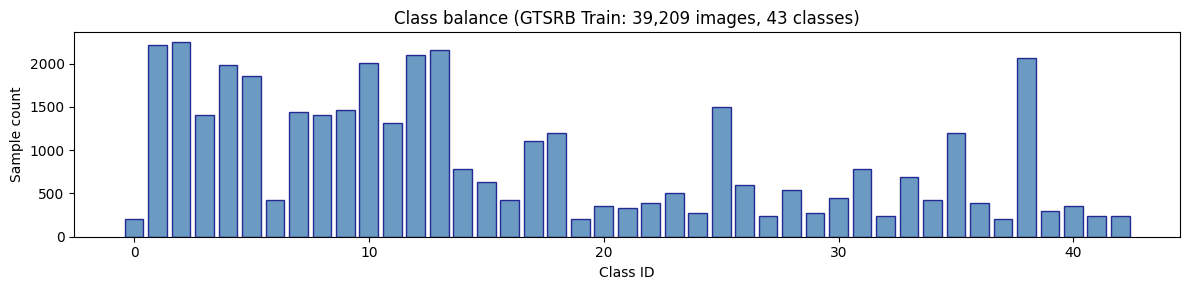

Most frequent class: 2 (2250 samples, 5.7%)
Least frequent class: 0 (210 samples, 0.5%)


In [ ]:
# Dataset structure & class balance (for requirements: Dataset overview)
print("=== GTSRB Dataset Structure ===")
print(f"Total samples: {len(data)}")
print(f"Input dimensions: {data.shape[1]}×{data.shape[2]}×{data.shape[3]} (H×W×C)")
print(f"Number of classes: {len(np.unique(labels))}")
# Per-class counts and balance
unique, counts = np.unique(labels, return_counts=True)
class_counts = dict(zip(unique, counts))
print(f"\nSamples per class: min={min(counts)}, max={max(counts)}, mean={np.mean(counts):.1f}")
# Class balance bar (compact)
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(unique, counts, color='steelblue', edgecolor='navy', alpha=0.8)
ax.set_xlabel('Class ID')
ax.set_ylabel('Sample count')
ax.set_title('Class balance (GTSRB Train: 39,209 images, 43 classes)')
plt.tight_layout()
plt.show()
# Imbalance summary
pcts = 100 * counts / len(labels)
print(f"Most frequent class: {unique[np.argmax(counts)]} ({max(counts)} samples, {max(pcts):.1f}%)")
print(f"Least frequent class: {unique[np.argmin(counts)]} ({min(counts)} samples, {min(pcts):.1f}%)")

**GTSRB class labels** — human-readable names for the 43 sign classes (used in confusion matrix, error analysis, demo).


In [ ]:
class_names = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)',
            2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)',
            4:'Speed limit (70km/h)',
            5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)',
            7:'Speed limit (100km/h)',
            8:'Speed limit (120km/h)',
            9:'No passing',
            10:'No passing veh over 3.5 tons',
            11:'Right-of-way at intersection',
            12:'Priority road',
            13:'Yield',
            14:'Stop',
            15:'No vehicles',
            16:'Veh > 3.5 tons prohibited',
            17:'No entry',
            18:'General caution',
            19:'Dangerous curve left',
            20:'Dangerous curve right',
            21:'Double curve',
            22:'Bumpy road',
            23:'Slippery road',
            24:'Road narrows on the right',
            25:'Road work',
            26:'Traffic signals',
            27:'Pedestrians',
            28:'Children crossing',
            29:'Bicycles crossing',
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits',
            33:'Turn right ahead',
            34:'Turn left ahead',
            35:'Ahead only',
            36:'Go straight or right',
            37:'Go straight or left',
            38:'Keep right',
            39:'Keep left',
            40:'Roundabout mandatory',
            41:'End of no passing',
            42:'End no passing veh > 3.5 tons' }

In [ ]:
print('Shape of Image Data: ' + str(data.shape))
print('Shape of Labels Data: ' + str(labels.shape))

Shape of Image Data: (39209, 30, 30, 3)
Shape of Labels Data: (39209,)


**1.3 Simple Baseline: Logistic Regression**

Fit Logistic Regression on flattened pixels (no spatial structure) to quantify the value added by the CNN architecture.

*Run data load and train_test_split cells above first. If you get `NameError`, run those cells and retry.*

In [ ]:
# Ensure split exists — run data load + split cells above first if you get NameError
if 'x_train' not in globals():
    try:
        x_trainval, x_test, y_trainval, y_test = train_test_split(data, labels, test_size=0.15, random_state=0)
        x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval, test_size=15/85, random_state=0)
    except NameError:
        raise RuntimeError("Run the data loading and train_test_split cells above first.")

# Flatten images for baseline (N, 30*30*3) = (N, 2700)
X_train_flat = x_train.reshape(x_train.shape[0], -1) / 255.0
X_test_flat = x_test.reshape(x_test.shape[0], -1) / 255.0

# Simple baseline: Logistic Regression
clf_baseline = LogisticRegression(max_iter=500, C=0.1, solver='lbfgs', n_jobs=-1)
clf_baseline.fit(X_train_flat, y_train)
y_pred_baseline = clf_baseline.predict(X_test_flat)
acc_baseline = (y_pred_baseline == y_test).mean()
print(f"Baseline (Logistic Regression) Test Accuracy: {acc_baseline:.4f}")

Baseline (Logistic Regression) Test Accuracy: 0.9238


*We can see that the shape of Image data and Labels is same*

In [ ]:
# 70% train, 15% validation, 15% test
x_trainval, x_test, y_trainval, y_test = train_test_split(data, labels, test_size=0.15, random_state=0)
x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval, test_size=15/85, random_state=0)
print(f'Train: {len(x_train)} ({100*len(x_train)/len(data):.1f}%) | Val: {len(x_val)} (15%) | Test: {len(x_test)} (15%)')

Train: 27445 (70.0%) | Val: 5882 (15%) | Test: 5882 (15%)


**Sanity check — data loading**  
High accuracy (98–99%) on GTSRB is **normal** for CNNs; the benchmark is well studied and not “too easy” when done correctly. To rule out bugs: (1) train/val/test are disjoint (same split, no overlap); (2) no test data in training; (3) labels match folder structure. Run the cell below to verify.

In [ ]:
# Sanity check: disjoint splits and correct sizes (run after train/val/test split cell)
assert len(x_train) + len(x_val) + len(x_test) == len(data), "Split sizes should sum to total"
assert np.unique(y_train).size <= 43 and np.unique(y_test).size <= 43, "Labels in 0..42"
print("OK: train/val/test sizes consistent; no overlap by construction (train_test_split).")
print("GTSRB 98–99% val accuracy is expected for CNNs; see benchmark leaderboards.")

OK: train/val/test sizes consistent; no overlap by construction (train_test_split).
GTSRB 98–99% val accuracy is expected for CNNs; see benchmark leaderboards.


In [ ]:
print('Train:', x_train.shape, y_train.shape)
print('Val:  ', x_val.shape, y_val.shape)
print('Test: ', x_test.shape, y_test.shape)

Train: (27445, 30, 30, 3) (27445,)
Val:   (5882, 30, 30, 3) (5882,)
Test:  (5882, 30, 30, 3) (5882,)


**Convert data for PyTorch** (labels stay as class indices; CrossEntropyLoss handles them)

In [ ]:
# Convert to tensors and normalize to [0,1]
x_train_t = torch.FloatTensor(x_train).permute(0, 3, 1, 2) / 255.0  # NCHW
x_val_t = torch.FloatTensor(x_val).permute(0, 3, 1, 2) / 255.0
x_test_t = torch.FloatTensor(x_test).permute(0, 3, 1, 2) / 255.0
y_train_t = torch.LongTensor(y_train)
y_val_t = torch.LongTensor(y_val)
y_test_t = torch.LongTensor(y_test)
train_dataset = TensorDataset(x_train_t, y_train_t)
val_dataset = TensorDataset(x_val_t, y_val_t)
test_dataset = TensorDataset(x_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**Data at 224×224 for ResNet (Model B)**  
Pretrained ResNet expects **224×224** input (ImageNet standard). We load the same dataset at 224 with the **same train/val/test split** (same `random_state`) so comparisons are fair. Class baselines (Basic/Complex CNN) use 30×30 above.

In [ ]:
# Load same dataset at 224x224 (same order: by class, then files) so split is identical
data_224 = []
labels_224 = []
for i in range(classes):
    for folder_name in [str(i), f"{i:05d}"]:
        path = cur_path / folder_name
        if path.exists():
            break
    if not path.exists():
        continue
    for f in path.iterdir():
        if f.suffix.lower() in ('.ppm', '.png', '.jpg', '.jpeg'):
            try:
                image = Image.open(f).convert('RGB')
                image = image.resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET))
                data_224.append(np.array(image))
                labels_224.append(i)
            except Exception as e:
                print(e)
data_224 = np.array(data_224)
labels_224 = np.array(labels_224)
# Same split as 30x30 data (same random_state)
x_trainval_224, x_test_224, y_trainval_224, y_test_224 = train_test_split(data_224, labels_224, test_size=0.15, random_state=0)
x_train_224, x_val_224, y_train_224, y_val_224 = train_test_split(x_trainval_224, y_trainval_224, test_size=15/85, random_state=0)
# PyTorch tensors and loaders for ResNet
x_train_t_224 = torch.FloatTensor(x_train_224).permute(0, 3, 1, 2) / 255.0
x_val_t_224 = torch.FloatTensor(x_val_224).permute(0, 3, 1, 2) / 255.0
x_test_t_224 = torch.FloatTensor(x_test_224).permute(0, 3, 1, 2) / 255.0
y_train_t_224 = torch.LongTensor(y_train_224)
y_val_t_224 = torch.LongTensor(y_val_224)
y_test_t_224 = torch.LongTensor(y_test_224)
train_loader_224 = DataLoader(TensorDataset(x_train_t_224, y_train_t_224), batch_size=32, shuffle=True, num_workers=0)
val_loader_224 = DataLoader(TensorDataset(x_val_t_224, y_val_t_224), batch_size=32, shuffle=False)
test_loader_224 = DataLoader(TensorDataset(x_test_t_224, y_test_t_224), batch_size=32, shuffle=False)
print(f"ResNet data: train {x_train_224.shape[0]}, val {x_val_224.shape[0]}, test {x_test_224.shape[0]} at 224x224")

ResNet data: train 27445, val 5882, test 5882 at 224x224


**Building Model (Basic CNN)**

In [ ]:
# Basic CNN: 2 conv layers + 1 fully connected
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 43)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = BasicCNN()
print('Basic CNN ready')
print(model)

Basic CNN ready
BasicCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=43, bias=True)
)


**Compile & Train Model (PyTorch)**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
epochs = 20
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
for ep in range(epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        correct += (out.argmax(1) == by).sum().item()
        total += by.size(0)
    history['loss'].append(train_loss / len(train_loader))
    history['accuracy'].append(correct / total)

    model.eval()
    val_loss, vcorrect, vtotal = 0, 0, 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            val_loss += criterion(out, by).item()
            vcorrect += (out.argmax(1) == by).sum().item()
            vtotal += by.size(0)
    history['val_loss'].append(val_loss / len(val_loader))
    history['val_accuracy'].append(vcorrect / vtotal)
    print(f"Epoch {ep+1}/{epochs} - loss: {history['loss'][-1]:.4f} - accuracy: {history['accuracy'][-1]:.4f} - val_loss: {history['val_loss'][-1]:.4f} - val_accuracy: {history['val_accuracy'][-1]:.4f}")

Epoch 1/20 - loss: 1.3442 - accuracy: 0.6172 - val_loss: 0.3636 - val_accuracy: 0.8995
Epoch 2/20 - loss: 0.2214 - accuracy: 0.9404 - val_loss: 0.1596 - val_accuracy: 0.9531
Epoch 3/20 - loss: 0.1100 - accuracy: 0.9710 - val_loss: 0.0965 - val_accuracy: 0.9752
Epoch 4/20 - loss: 0.0760 - accuracy: 0.9804 - val_loss: 0.1000 - val_accuracy: 0.9716
Epoch 5/20 - loss: 0.0485 - accuracy: 0.9868 - val_loss: 0.0653 - val_accuracy: 0.9823
Epoch 6/20 - loss: 0.0441 - accuracy: 0.9877 - val_loss: 0.1540 - val_accuracy: 0.9548
Epoch 7/20 - loss: 0.0292 - accuracy: 0.9921 - val_loss: 0.0582 - val_accuracy: 0.9859
Epoch 8/20 - loss: 0.0305 - accuracy: 0.9915 - val_loss: 0.0549 - val_accuracy: 0.9878
Epoch 9/20 - loss: 0.0173 - accuracy: 0.9953 - val_loss: 0.0628 - val_accuracy: 0.9849
Epoch 10/20 - loss: 0.0238 - accuracy: 0.9939 - val_loss: 0.0542 - val_accuracy: 0.9864
Epoch 11/20 - loss: 0.0204 - accuracy: 0.9946 - val_loss: 0.0449 - val_accuracy: 0.9893
Epoch 12/20 - loss: 0.0132 - accuracy: 0.

**Accuracy**

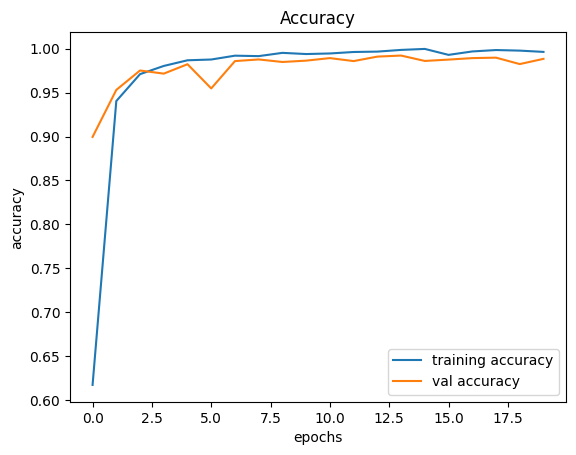

In [ ]:
plt.figure(0)
plt.plot(history['accuracy'], label='training accuracy')
plt.plot(history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

Here what we can observe is that for 20 Epochs

*Accuracy is 0.9422*

*Validation Accuracy is 0.9843*

**Loss**

**Hyperparameter Exploration:** Train Basic CNN with different learning rates and batch sizes to compare convergence.

lr=1e-4, bs=32: best val_acc = 0.9470
lr=5e-4, bs=32: best val_acc = 0.9803
lr=1e-3, bs=32: best val_acc = 0.9886
lr=1e-3, bs=64: best val_acc = 0.9849
lr=1e-3, bs=32, wd=1e-4: best val_acc = 0.9867
lr=1e-3, bs=32, wd=1e-2: best val_acc = 0.9320


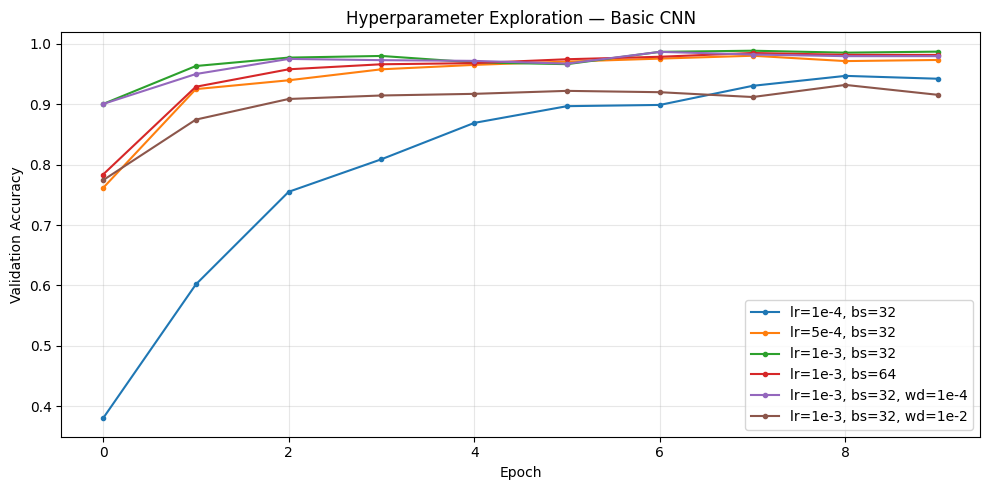

In [ ]:
# Hyperparameter exploration: lr and batch size (10 epochs each for speed)
HP_EPOCHS = 10
configs = [
    {"lr": 1e-4, "batch_size": 32, "weight_decay": 0, "label": "lr=1e-4, bs=32"},
    {"lr": 5e-4, "batch_size": 32, "weight_decay": 0, "label": "lr=5e-4, bs=32"},
    {"lr": 1e-3, "batch_size": 32, "weight_decay": 0, "label": "lr=1e-3, bs=32"},
    {"lr": 1e-3, "batch_size": 64, "weight_decay": 0, "label": "lr=1e-3, bs=64"},
    {"lr": 1e-3, "batch_size": 32, "weight_decay": 1e-4, "label": "lr=1e-3, bs=32, wd=1e-4"},
    {"lr": 1e-3, "batch_size": 32, "weight_decay": 1e-2, "label": "lr=1e-3, bs=32, wd=1e-2"},
]
hp_histories = {}

for cfg in configs:
    set_seed(42)
    loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], shuffle=True, num_workers=0)
    m = BasicCNN().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=cfg["lr"], weight_decay=cfg.get("weight_decay", 0))
    hist = {"val_accuracy": []}
    for ep in range(HP_EPOCHS):
        m.train()
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad()
            loss = criterion(m(bx), by)
            loss.backward()
            opt.step()
        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                correct += (m(bx).argmax(1) == by).sum().item()
                total += by.size(0)
        hist["val_accuracy"].append(correct / total)
    hp_histories[cfg["label"]] = hist
    print(f"{cfg['label']}: best val_acc = {max(hist['val_accuracy']):.4f}")

plt.figure(figsize=(10, 5))
for label, hist in hp_histories.items():
    plt.plot(hist["val_accuracy"], label=label, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Hyperparameter Exploration — Basic CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

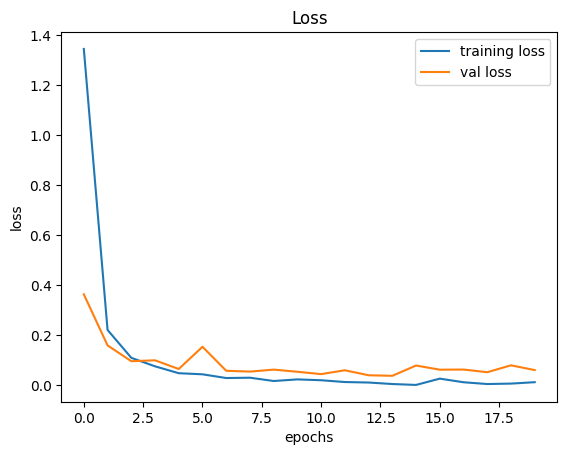

In [ ]:
plt.plot(history['loss'], label='training loss')
plt.plot(history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

**Extended Hyperparameter Tuning: LR Scheduler & Early Stopping**

Compare training with/without learning rate scheduler (ReduceLROnPlateau) and early stopping. Ablation on regularization (weight decay above) and training tricks.

Early stop at epoch 8

No scheduler, no early stop: best val_acc = 0.9893
With scheduler: best val_acc = 0.9878
With scheduler + early stop: best val_acc = 0.9796


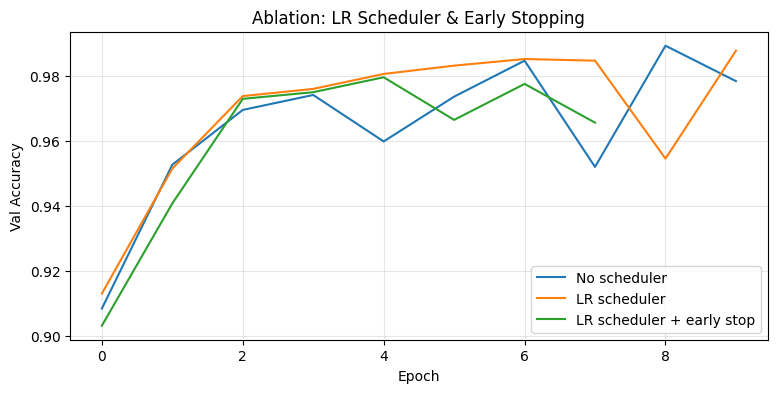

In [ ]:
# Ablation: LR scheduler + early stopping (10 epochs max, early stop if no improvement for 3)
def train_with_scheduler(use_scheduler=True, use_early_stop=True, patience=3):
    set_seed(42)
    m = BasicCNN().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2) if use_scheduler else None
    hist = {"val_accuracy": [], "lr": []}
    best_val, best_epoch, no_improve = 0, 0, 0
    for ep in range(10):
        m.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad()
            criterion(m(bx), by).backward()
            opt.step()
        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                correct += (m(bx).argmax(1) == by).sum().item()
                total += by.size(0)
        val_acc = correct / total
        hist["val_accuracy"].append(val_acc)
        hist["lr"].append(opt.param_groups[0]["lr"])
        if scheduler: scheduler.step(val_acc)
        if val_acc > best_val:
            best_val, best_epoch, no_improve = val_acc, ep, 0
        else:
            no_improve += 1
        if use_early_stop and no_improve >= patience:
            print(f"Early stop at epoch {ep+1}")
            break
    return hist, best_val

h1, v1 = train_with_scheduler(use_scheduler=False, use_early_stop=False)
h2, v2 = train_with_scheduler(use_scheduler=True, use_early_stop=False)
h3, v3 = train_with_scheduler(use_scheduler=True, use_early_stop=True)
print(f"\nNo scheduler, no early stop: best val_acc = {v1:.4f}")
print(f"With scheduler: best val_acc = {v2:.4f}")
print(f"With scheduler + early stop: best val_acc = {v3:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(h1["val_accuracy"], label="No scheduler")
plt.plot(h2["val_accuracy"], label="LR scheduler")
plt.plot(h3["val_accuracy"], label="LR scheduler + early stop")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy")
plt.title("Ablation: LR Scheduler & Early Stopping"); plt.legend(); plt.grid(alpha=0.3); plt.show()

### Final Baseline CNN after updating with hyperparameters from above

In [ ]:
import time
from statistics import mean

# Basic CNN with best setup: lr=1e-3, bs=32, weight_decay=1e-4 (no LR scheduler for Model A)
set_seed(42)
model = BasicCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 20
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

epoch_times = []
train_start_time = time.time()

for ep in range(epochs):
    ep_start = time.time()

    model.train()
    train_loss, correct, total = 0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        correct += (out.argmax(1) == by).sum().item()
        total += by.size(0)
    history['loss'].append(train_loss / len(train_loader))
    history['accuracy'].append(correct / total)

    model.eval()
    val_loss, vcorrect, vtotal = 0, 0, 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            val_loss += criterion(out, by).item()
            vcorrect += (out.argmax(1) == by).sum().item()
            vtotal += by.size(0)
    history['val_loss'].append(val_loss / len(val_loader))
    history['val_accuracy'].append(vcorrect / vtotal)

    ep_time = time.time() - ep_start
    epoch_times.append(ep_time)

    print(
        f"Epoch {ep+1}/{epochs} - "
        f"loss: {history['loss'][-1]:.4f} - "
        f"accuracy: {history['accuracy'][-1]:.4f} - "
        f"val_loss: {history['val_loss'][-1]:.4f} - "
        f"val_accuracy: {history['val_accuracy'][-1]:.4f} - "
        f"epoch_time: {ep_time:.2f}s"
    )

total_train_time = time.time() - train_start_time

print(f"Basic CNN (best setup) ready. Best val accuracy: {max(history['val_accuracy']):.4f}")
print(f"Basic CNN avg epoch time: {mean(epoch_times):.2f}s")
print(f"Basic CNN total training time: {total_train_time/60:.2f} min "
      f"({total_train_time/3600:.2f} hours)")

Epoch 1/20 - loss: 1.3564 - accuracy: 0.6114 - val_loss: 0.3463 - val_accuracy: 0.9104 - epoch_time: 2.61s
Epoch 2/20 - loss: 0.2317 - accuracy: 0.9370 - val_loss: 0.1735 - val_accuracy: 0.9546 - epoch_time: 2.63s
Epoch 3/20 - loss: 0.1208 - accuracy: 0.9691 - val_loss: 0.1162 - val_accuracy: 0.9675 - epoch_time: 2.62s
Epoch 4/20 - loss: 0.0766 - accuracy: 0.9808 - val_loss: 0.1016 - val_accuracy: 0.9713 - epoch_time: 2.62s
Epoch 5/20 - loss: 0.0594 - accuracy: 0.9840 - val_loss: 0.0937 - val_accuracy: 0.9706 - epoch_time: 2.65s
Epoch 6/20 - loss: 0.0459 - accuracy: 0.9875 - val_loss: 0.1108 - val_accuracy: 0.9696 - epoch_time: 2.50s
Epoch 7/20 - loss: 0.0321 - accuracy: 0.9916 - val_loss: 0.0547 - val_accuracy: 0.9857 - epoch_time: 2.52s
Epoch 8/20 - loss: 0.0307 - accuracy: 0.9914 - val_loss: 0.0643 - val_accuracy: 0.9845 - epoch_time: 2.51s
Epoch 9/20 - loss: 0.0326 - accuracy: 0.9911 - val_loss: 0.0908 - val_accuracy: 0.9745 - epoch_time: 2.54s
Epoch 10/20 - loss: 0.0216 - accuracy

---
## Complex CNN

Deeper model with more capacity (4 conv blocks, BatchNorm, Dropout), built after analyzing Basic CNN results.

In [ ]:
# Complex CNN: 4 conv blocks (32→64→128→256), BatchNorm, Dropout, deeper FC
class ComplexCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.25)
        self.fc1 = nn.Linear(256 * 1 * 1, 256)  # 30→15→7→3→1 after 4 pools
        self.fc2 = nn.Linear(256, 43)

    def forward(self, x):
        x = self.drop(self.pool(torch.relu(self.bn1(self.conv1(x)))))
        x = self.drop(self.pool(torch.relu(self.bn2(self.conv2(x)))))
        x = self.drop(self.pool(torch.relu(self.bn3(self.conv3(x)))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_complex = ComplexCNN().to(device)
optimizer_complex = torch.optim.Adam(model_complex.parameters(), lr=1e-3)
print('Complex CNN ready')

Complex CNN ready


In [ ]:
# Train Complex CNN
history_complex = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
epochs = 20
for ep in range(epochs):
    model_complex.train()
    train_loss, correct, total = 0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer_complex.zero_grad()
        out = model_complex(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer_complex.step()
        train_loss += loss.item()
        correct += (out.argmax(1) == by).sum().item()
        total += by.size(0)
    history_complex['loss'].append(train_loss / len(train_loader))
    history_complex['accuracy'].append(correct / total)

    model_complex.eval()
    val_loss, vcorrect, vtotal = 0, 0, 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            out = model_complex(bx)
            val_loss += criterion(out, by).item()
            vcorrect += (out.argmax(1) == by).sum().item()
            vtotal += by.size(0)
    history_complex['val_loss'].append(val_loss / len(val_loader))
    history_complex['val_accuracy'].append(vcorrect / vtotal)
    print(f"Epoch {ep+1}/{epochs} - loss: {history_complex['loss'][-1]:.4f} - acc: {history_complex['accuracy'][-1]:.4f} - val_acc: {history_complex['val_accuracy'][-1]:.4f}")

Epoch 1/20 - loss: 1.3071 - acc: 0.5923 - val_acc: 0.8977
Epoch 2/20 - loss: 0.3153 - acc: 0.8936 - val_acc: 0.9770
Epoch 3/20 - loss: 0.1882 - acc: 0.9373 - val_acc: 0.9842
Epoch 4/20 - loss: 0.1356 - acc: 0.9559 - val_acc: 0.9874
Epoch 5/20 - loss: 0.1134 - acc: 0.9639 - val_acc: 0.9915
Epoch 6/20 - loss: 0.0962 - acc: 0.9690 - val_acc: 0.9930
Epoch 7/20 - loss: 0.0869 - acc: 0.9710 - val_acc: 0.9969
Epoch 8/20 - loss: 0.0703 - acc: 0.9765 - val_acc: 0.9923
Epoch 9/20 - loss: 0.0639 - acc: 0.9787 - val_acc: 0.9944
Epoch 10/20 - loss: 0.0681 - acc: 0.9775 - val_acc: 0.9923
Epoch 11/20 - loss: 0.0598 - acc: 0.9813 - val_acc: 0.9949
Epoch 12/20 - loss: 0.0527 - acc: 0.9821 - val_acc: 0.9949
Epoch 13/20 - loss: 0.0498 - acc: 0.9835 - val_acc: 0.9956
Epoch 14/20 - loss: 0.0521 - acc: 0.9826 - val_acc: 0.9969
Epoch 15/20 - loss: 0.0457 - acc: 0.9851 - val_acc: 0.9963
Epoch 16/20 - loss: 0.0374 - acc: 0.9876 - val_acc: 0.9973
Epoch 17/20 - loss: 0.0464 - acc: 0.9851 - val_acc: 0.9963
Epoch 

So we can observe that

*Feature loss is 0.2349*

*Validation loss is 0.0572*

**1.4 Analytical Insights:** Confusion matrix, per-class accuracy, error analysis

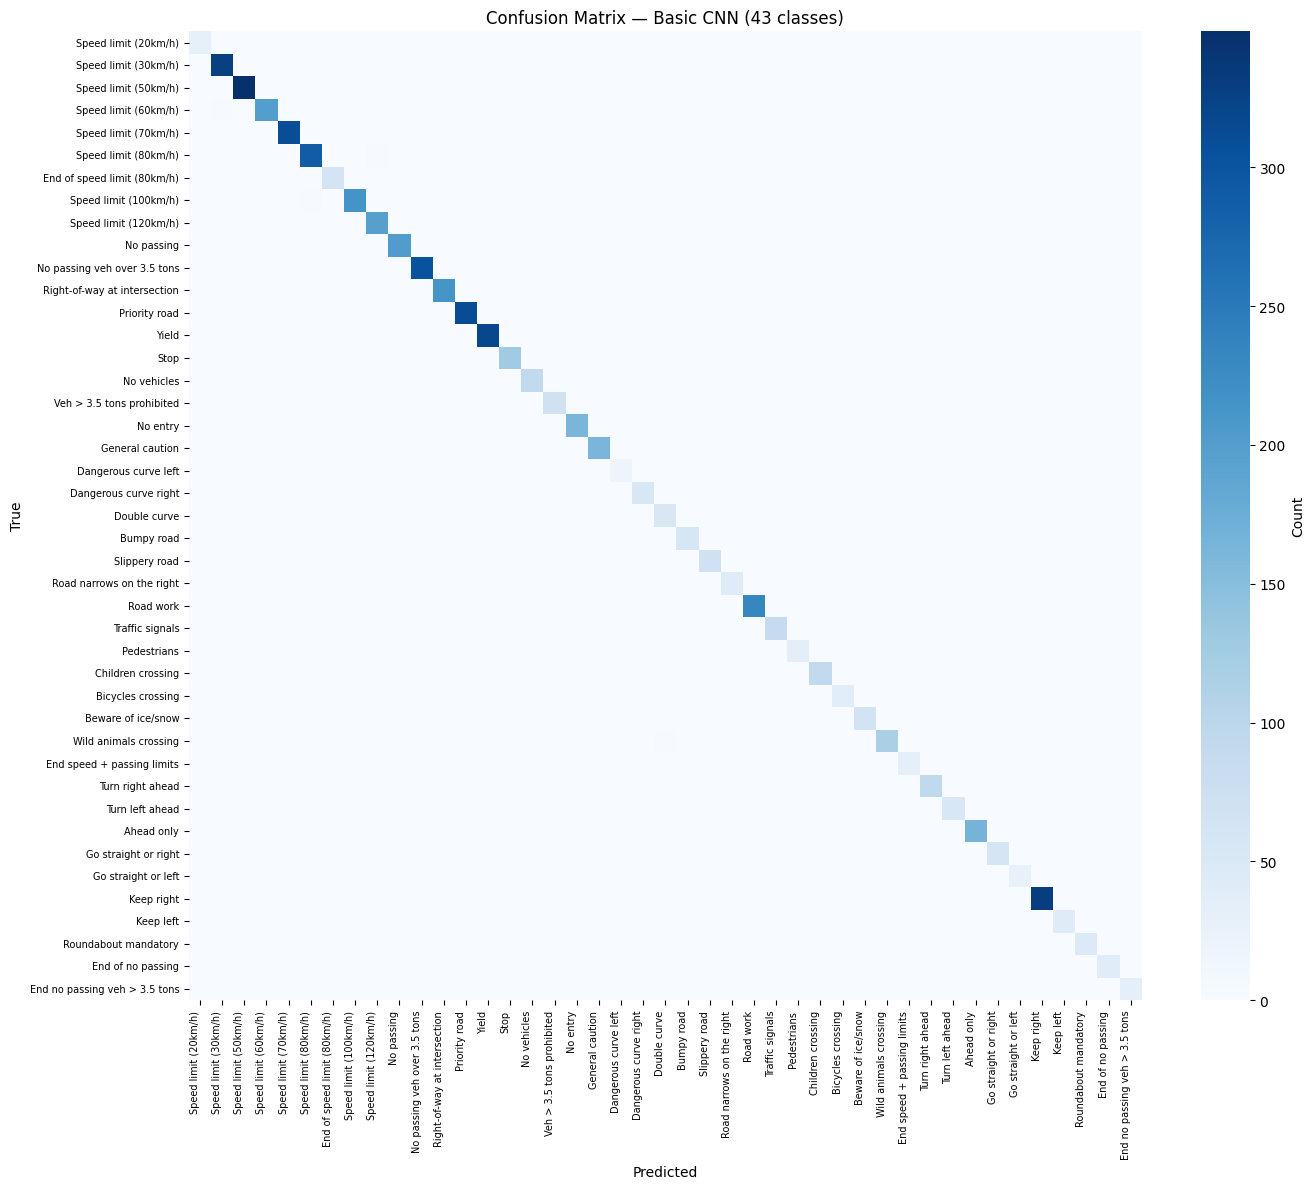

Hardest 5 classes (lowest accuracy):
  Go straight or left: 0.933 (n=30)
  Dangerous curve right: 0.965 (n=57)
  Children crossing: 0.968 (n=93)
  End speed + passing limits: 0.970 (n=33)
  Wild animals crossing: 0.975 (n=119)


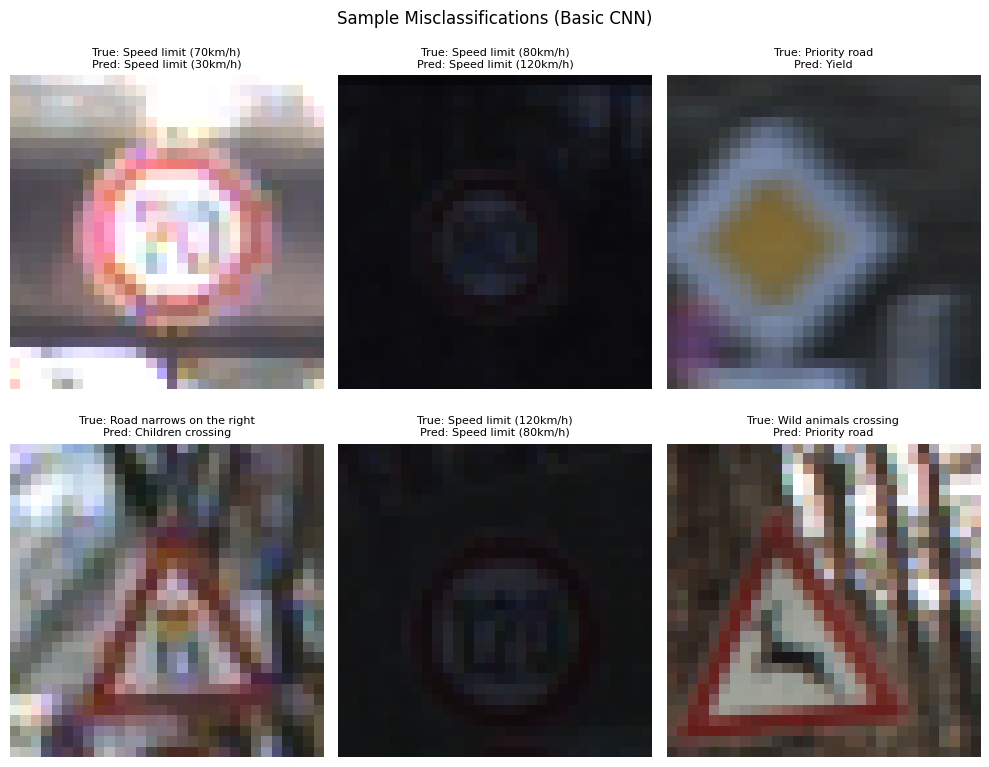

In [ ]:
# Get CNN predictions for analysis
model.eval()
y_pred_cnn = []
with torch.no_grad():
    for bx, _ in test_loader:
        bx = bx.to(device)
        out = model(bx)
        y_pred_cnn.extend(out.argmax(1).cpu().numpy())
y_pred_cnn = np.array(y_pred_cnn)

# Confusion matrix (Basic CNN)
cm = confusion_matrix(y_test, y_pred_cnn)
labels = [class_names[i] for i in range(43)]
plt.figure(figsize=(14, 12))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues', cbar_kws={'label': 'Count'}, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.title('Confusion Matrix — Basic CNN (43 classes)')
plt.tight_layout()
plt.show()

# Per-class accuracy: hardest classes
class_acc = []
for c in range(43):
    mask = y_test == c
    if mask.sum() > 0:
        acc = (y_pred_cnn[mask] == y_test[mask]).mean()
        class_acc.append((c, acc, mask.sum()))
class_acc.sort(key=lambda x: x[1])
print("Hardest 5 classes (lowest accuracy):")
for c, acc, n in class_acc[:5]:
    print(f"  {class_names[c]}: {acc:.3f} (n={n})")

# Sample misclassifications (Basic CNN)
wrong_idx = np.where(y_pred_cnn != y_test)[0]
if len(wrong_idx) > 0:
    n_show = min(6, len(wrong_idx))
    rng = np.random.default_rng(42)
    samp = rng.choice(wrong_idx, n_show, replace=False)
    fig, axes = plt.subplots(2, 3, figsize=(10, 8))
    for i, ax in enumerate(axes.flat):
        if i < len(samp):
            idx = samp[i]
            ax.imshow(x_test[idx])
            t, p = class_names[y_test[idx]], class_names[y_pred_cnn[idx]]
            ax.set_title(f"True: {t}\nPred: {p}", fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample Misclassifications (Basic CNN)')
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications for Basic CNN.")

---
## CNN Evaluation: Compare Models & Test on Clean Data

Compare Basic vs Complex CNN training curves, then evaluate both on the held-out test set (15%).

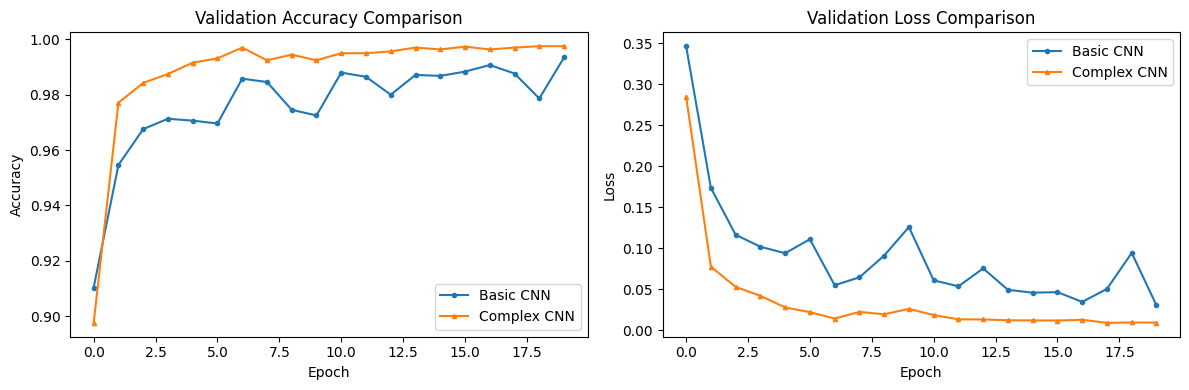

Basic CNN best val accuracy:  0.9934
Complex CNN best val accuracy: 0.9974


In [ ]:
# Compare: Basic vs Complex CNN
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['val_accuracy'], label='Basic CNN', marker='o', markersize=3)
plt.plot(history_complex['val_accuracy'], label='Complex CNN', marker='^', markersize=3)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_loss'], label='Basic CNN', marker='o', markersize=3)
plt.plot(history_complex['val_loss'], label='Complex CNN', marker='^', markersize=3)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Basic CNN best val accuracy:  {max(history['val_accuracy']):.4f}")
print(f"Complex CNN best val accuracy: {max(history_complex['val_accuracy']):.4f}")

In [ ]:
# Final evaluation on held-out test set (15%)
def eval_test(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            correct += (out.argmax(1) == by).sum().item()
            total += by.size(0)
    return correct / total

# 1.3 Baseline vs Deep Model Comparison
acc_cnn = eval_test(model, test_loader)
print("Test set accuracy (held-out 15%):")
print(f"  Baseline (Logistic Regression): {acc_baseline:.4f}")
print(f"  Basic CNN:     {acc_cnn:.4f}")
print(f"  Complex CNN:   {eval_test(model_complex, test_loader):.4f}")
print(f"\n  CNN gain over baseline: +{(acc_cnn - acc_baseline)*100:.1f} pp")

Test set accuracy (held-out 15%):
  Baseline (Logistic Regression): 0.9238
  Basic CNN:     0.9915
  Complex CNN:   0.9968

  CNN gain over baseline: +6.8 pp


---
## Transfer Learning: Pretrained ResNet (Model B)

**Directions:** *"Advanced / transfer baseline: e.g., pretrained ResNet / EfficientNet."*  
Using **Hugging Face** `ResNetForImageClassification` (`microsoft/resnet-50`), pretrained on ImageNet. Expects **224×224** input with ImageNet normalization. Replace the classifier head for 43 classes, then finetune.

In [ ]:
import torch
import time
from statistics import mean
from transformers import ResNetForImageClassification
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device("cuda")  # fail fast if no GPU
assert torch.cuda.is_available(), "CUDA not available, but GPU was requested."

NUM_CLASSES = 43
model_resnet = ResNetForImageClassification.from_pretrained(
    "microsoft/resnet-50",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(device)  # model on GPU

opt_resnet = torch.optim.Adam(model_resnet.parameters(), lr=1e-4)
scheduler_resnet = CosineAnnealingLR(opt_resnet, T_max=15, eta_min=1e-6)

# ImageNet normalization for pretrained models (also on GPU)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

total_params = sum(p.numel() for p in model_resnet.parameters())
trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"ResNet50: {trainable_params:,} trainable / {total_params:,} total params. Ready for 43 classes.")

history_resnet = {'loss': [], 'val_accuracy': []}
best_val_acc = 0
patience, no_improve = 3, 0

resnet_epoch_times = []
resnet_start_time = time.time()

for ep in range(15):
    ep_start = time.time()

    model_resnet.train()
    train_loss, correct, total = 0, 0, 0
    for bx, by in train_loader_224:
        bx, by = bx.to(device), by.to(device)  # batches to GPU
        bx_norm = (bx - IMAGENET_MEAN) / IMAGENET_STD
        opt_resnet.zero_grad()
        out = model_resnet(pixel_values=bx_norm).logits
        loss = criterion(out, by)
        loss.backward()
        opt_resnet.step()
        train_loss += loss.item()
        correct += (out.argmax(1) == by).sum().item()
        total += by.size(0)

    scheduler_resnet.step()

    model_resnet.eval()
    vcorrect, vtotal = 0, 0
    with torch.no_grad():
        for bx, by in val_loader_224:
            bx, by = bx.to(device), by.to(device)
            bx_norm = (bx - IMAGENET_MEAN) / IMAGENET_STD
            vcorrect += (model_resnet(pixel_values=bx_norm).logits.argmax(1) == by).sum().item()
            vtotal += by.size(0)
    val_acc = vcorrect / vtotal
    history_resnet['loss'].append(train_loss / len(train_loader_224))
    history_resnet['val_accuracy'].append(val_acc)

    ep_time = time.time() - ep_start
    resnet_epoch_times.append(ep_time)

    print(
        f"ResNet Epoch {ep+1}/15 - "
        f"loss: {history_resnet['loss'][-1]:.4f} - "
        f"val_acc: {val_acc:.4f} - "
        f"epoch_time: {ep_time:.2f}s"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"Early stop at epoch {ep+1}")
        break

resnet_total_time = time.time() - resnet_start_time
print(f"ResNet avg epoch time: {mean(resnet_epoch_times):.2f}s")
print(f"ResNet total training time: {resnet_total_time/60:.2f} min "
      f"({resnet_total_time/3600:.2f} hours)")

# Test accuracy (HF model uses pixel_values)
resnet_test_correct, resnet_test_total = 0, 0
model_resnet.eval()
with torch.no_grad():
    for bx, by in test_loader_224:
        bx, by = bx.to(device), by.to(device)
        bx_norm = (bx - IMAGENET_MEAN) / IMAGENET_STD
        resnet_test_correct += (model_resnet(pixel_values=bx_norm).logits.argmax(1) == by).sum().item()
        resnet_test_total += by.size(0)
resnet_test_acc = resnet_test_correct / resnet_test_total
print(f"ResNet (Hugging Face, pretrained) test accuracy: {resnet_test_acc:.4f}")

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                           
--------------------+----------+-------------------------------------------------------------------------------------------
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([43])            
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([43, 2048])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ResNet50: 23,596,139 trainable / 23,596,139 total params. Ready for 43 classes.
ResNet Epoch 1/15 - loss: 1.3863 - val_acc: 0.9765 - epoch_time: 41.70s
ResNet Epoch 2/15 - loss: 0.0650 - val_acc: 0.9959 - epoch_time: 41.24s
ResNet Epoch 3/15 - loss: 0.0195 - val_acc: 0.9973 - epoch_time: 41.35s
ResNet Epoch 4/15 - loss: 0.0088 - val_acc: 0.9981 - epoch_time: 41.28s
ResNet Epoch 5/15 - loss: 0.0046 - val_acc: 0.9969 - epoch_time: 41.05s
ResNet Epoch 6/15 - loss: 0.0027 - val_acc: 0.9985 - epoch_time: 41.35s
ResNet Epoch 7/15 - loss: 0.0025 - val_acc: 0.9986 - epoch_time: 41.17s
ResNet Epoch 8/15 - loss: 0.0024 - val_acc: 0.9986 - epoch_time: 41.12s
ResNet Epoch 9/15 - loss: 0.0014 - val_acc: 0.9986 - epoch_time: 41.08s
ResNet Epoch 10/15 - loss: 0.0009 - val_acc: 0.9985 - epoch_time: 41.77s
Early stop at epoch 10
ResNet avg epoch time: 41.31s
ResNet total training time: 6.89 min (0.11 hours)
ResNet (Hugging Face, pretrained) test accuracy: 0.9986


### ResNet training curves

In [ ]:
# ResNet training & validation curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_resnet['loss'], label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('ResNet — Train Loss')
plt.subplot(1, 2, 2)
plt.plot(history_resnet['val_accuracy'], label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ResNet — Validation Accuracy')
plt.tight_layout()
plt.show()

### Recall per class


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# ResNet predictions (y_test_224, y_pred_resnet from your get_metrics / eval)
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test_224, y_pred_resnet, average=None, zero_division=0
)

# Print recall per class
print("Recall per class (ResNet):")
for c in range(43):
    print(f"  {class_names[c]}: {recall_per_class[c]:.4f}")

In [ ]:
import pandas as pd
recall_df = pd.DataFrame({
    'Class': [class_names[c] for c in range(43)],
    'Recall': recall_per_class
})
print(recall_df.to_string(index=False))

### Results Summary

**Table:** Model | Val Acc | Test Acc (primary) | Precision | Recall | F1 (macro avg)  
**Class-wise metrics** via classification_report. **Comparison:** class baseline (Log Reg) vs CNNs vs pretrained ResNet.

RESULTS TABLE (per directions): Model | Val Acc | Test Acc | Precision | Recall | F1
Model              Val Acc    Test Acc   Precision  Recall     F1        
------------------------------------------------------------------------------------------
Baseline (LogReg)  N/A        0.9238     0.9393     0.9004     0.9175    
Basic CNN          0.9934     0.9915     0.9905     0.9906     0.9905    
Complex CNN        0.9974     0.9968     0.9961     0.9953     0.9957    
ResNet (pretrained) 0.9986     0.9986     0.9989     0.9988     0.9989    

Class-wise metrics (classification_report) — ResNet:
                               precision    recall  f1-score   support

         Speed limit (20km/h)       1.00      1.00      1.00        30
         Speed limit (30km/h)       0.99      1.00      1.00       331
         Speed limit (50km/h)       1.00      0.99      1.00       353
         Speed limit (60km/h)       1.00      1.00      1.00       204
         Speed limit (70km/h)       1.00   

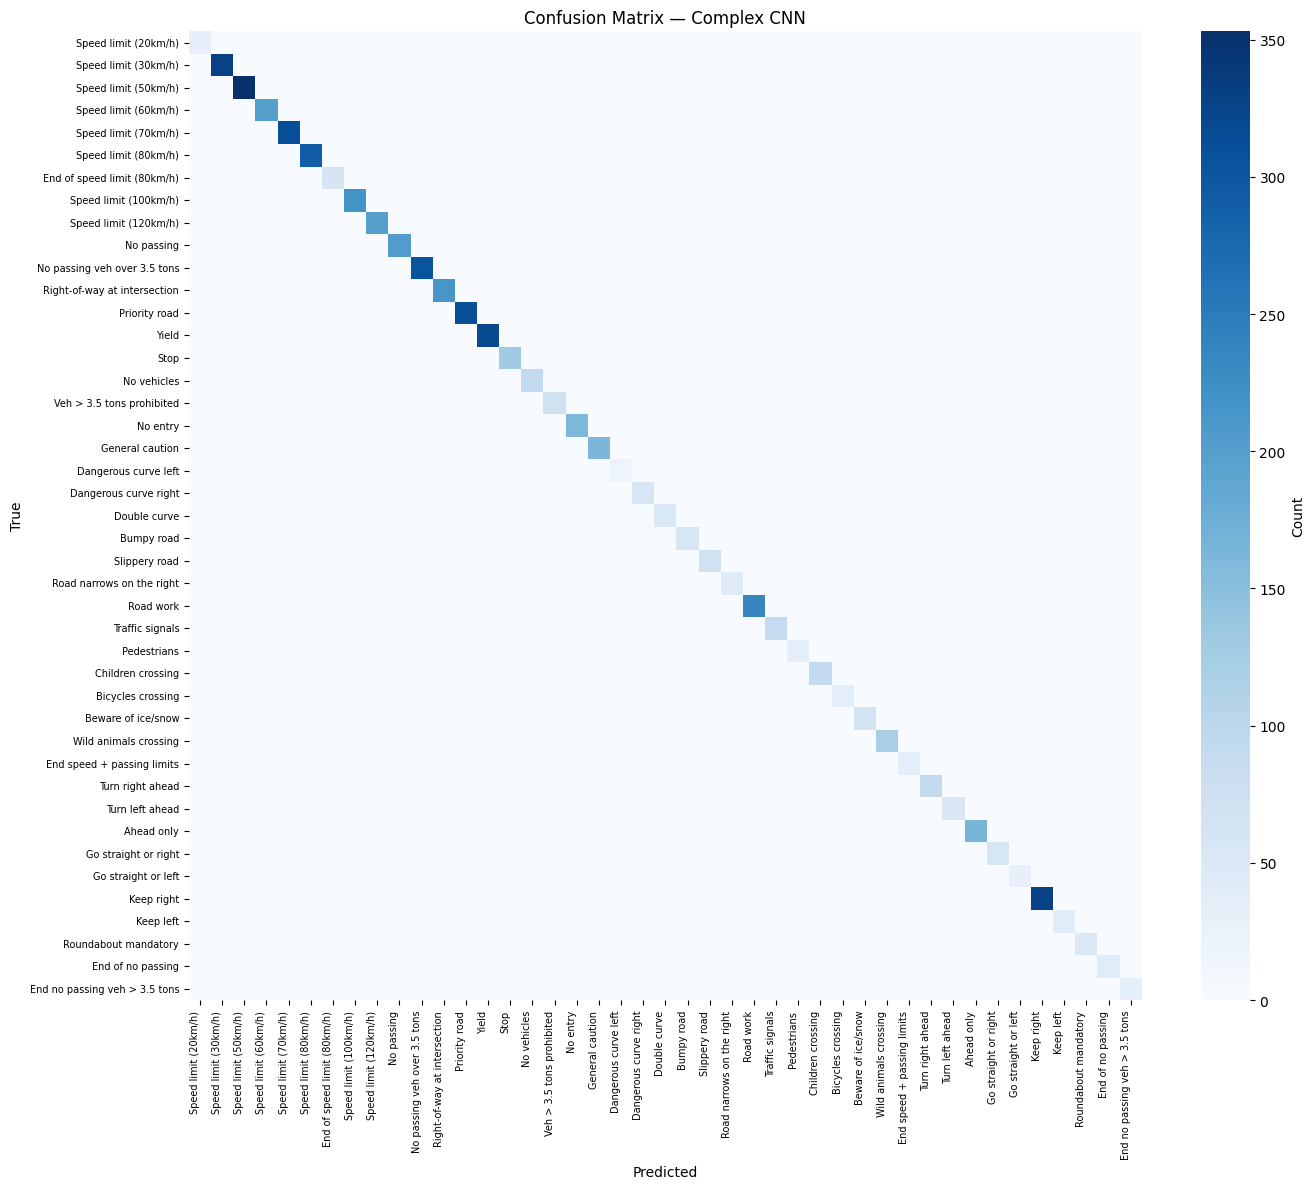

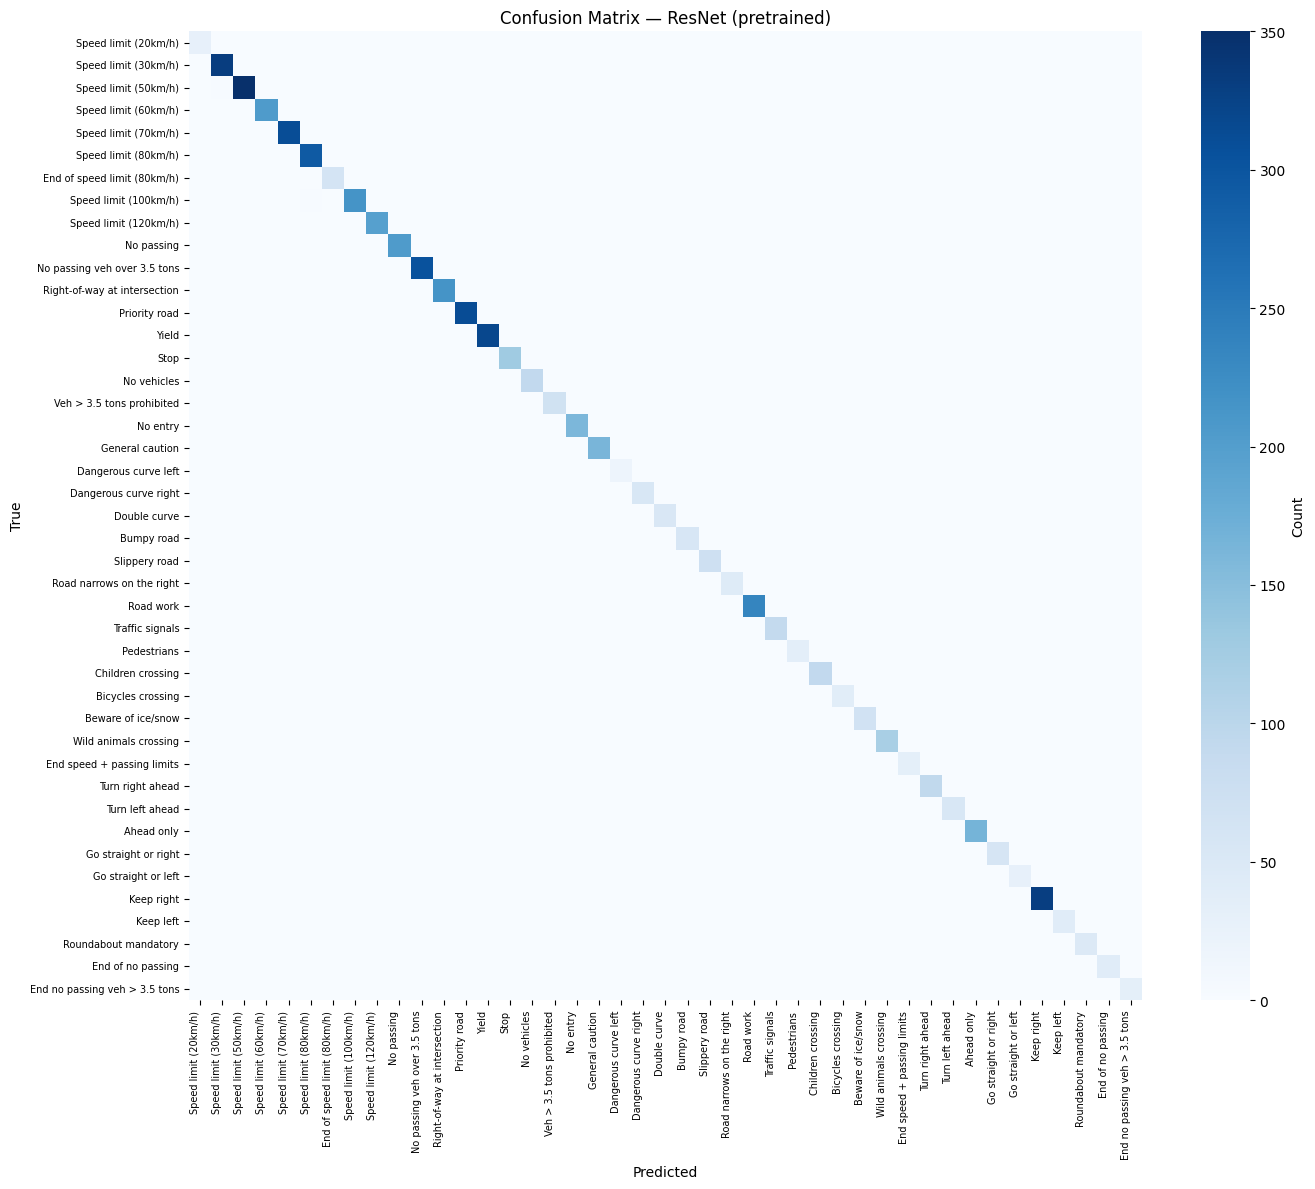

In [ ]:
# Get predictions for Complex CNN and ResNet (Basic CNN has y_pred_cnn from Analytical Insights)
model_complex.eval()
y_pred_complex = []
with torch.no_grad():
    for bx, _ in test_loader:
        bx = bx.to(device)
        y_pred_complex.extend(model_complex(bx).argmax(1).cpu().numpy())
y_pred_complex = np.array(y_pred_complex)

model_resnet.eval()
y_pred_resnet = []
with torch.no_grad():
    for bx, by in test_loader_224:
        bx = bx.to(device)
        bx_norm = (bx - IMAGENET_MEAN) / IMAGENET_STD
        y_pred_resnet.extend(model_resnet(pixel_values=bx_norm).logits.argmax(1).cpu().numpy())
y_pred_resnet = np.array(y_pred_resnet)

# Val metrics (best epoch)
val_basic = max(history['val_accuracy'])
val_complex = max(history_complex['val_accuracy'])
val_resnet = max(history_resnet['val_accuracy']) if history_resnet['val_accuracy'] else 0

# Classification reports (macro avg for precision, recall, f1)
from sklearn.metrics import precision_recall_fscore_support
r_baseline = precision_recall_fscore_support(y_test, y_pred_baseline, average='macro')
r_basic = precision_recall_fscore_support(y_test, y_pred_cnn, average='macro')
r_complex = precision_recall_fscore_support(y_test, y_pred_complex, average='macro')
r_resnet = precision_recall_fscore_support(y_test_224, y_pred_resnet, average='macro')

# Results table
print("=" * 90)
print("RESULTS TABLE (per directions): Model | Val Acc | Test Acc | Precision | Recall | F1")
print("=" * 90)
print(f"{'Model':<18} {'Val Acc':<10} {'Test Acc':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 90)
print(f"{'Baseline (LogReg)':<18} {'N/A':<10} {acc_baseline:<10.4f} {r_baseline[0]:<10.4f} {r_baseline[1]:<10.4f} {r_baseline[2]:<10.4f}")
print(f"{'Basic CNN':<18} {val_basic:<10.4f} {eval_test(model, test_loader):<10.4f} {r_basic[0]:<10.4f} {r_basic[1]:<10.4f} {r_basic[2]:<10.4f}")
print(f"{'Complex CNN':<18} {val_complex:<10.4f} {eval_test(model_complex, test_loader):<10.4f} {r_complex[0]:<10.4f} {r_complex[1]:<10.4f} {r_complex[2]:<10.4f}")
print(f"{'ResNet (pretrained)':<18} {val_resnet:<10.4f} {resnet_test_acc:<10.4f} {r_resnet[0]:<10.4f} {r_resnet[1]:<10.4f} {r_resnet[2]:<10.4f}")
print("=" * 90)
print("\nClass-wise metrics (classification_report) — ResNet:")
print(classification_report(y_test_224, y_pred_resnet, target_names=[class_names[i] for i in range(43)], digits=2))

# Complex CNN confusion matrix
cm_complex = confusion_matrix(y_test, y_pred_complex)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_complex, xticklabels=labels, yticklabels=labels, cmap='Blues', cbar_kws={'label': 'Count'}, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.title('Confusion Matrix — Complex CNN')
plt.tight_layout()
plt.show()

# ResNet confusion matrix
cm_resnet = confusion_matrix(y_test_224, y_pred_resnet)
labels = [class_names[i] for i in range(43)]
plt.figure(figsize=(14, 12))
sns.heatmap(cm_resnet, xticklabels=labels, yticklabels=labels, cmap='Blues', cbar_kws={'label': 'Count'}, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.title('Confusion Matrix — ResNet (pretrained)')
plt.tight_layout()
plt.show()



---



### Plot and table with baseline cnn and resnet for slides

In [ ]:
# Combined: Basic CNN vs ResNet — Training & validation curves (1 plot per slide)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Training Loss
axes[0].plot(history['loss'], label='Basic CNN', marker='o', markersize=3)
axes[0].plot(history_resnet['loss'], label='ResNet', marker='^', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Validation Accuracy
axes[1].plot(history['val_accuracy'], label='Basic CNN', marker='o', markersize=3)
axes[1].plot(history_resnet['val_accuracy'], label='ResNet', marker='^', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Results table: Model | Val Acc | Test Acc | Precision | Recall | F1
from sklearn.metrics import precision_recall_fscore_support, classification_report

def get_metrics(model, test_loader, is_resnet=False):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            if is_resnet:
                bx_norm = (bx - IMAGENET_MEAN) / IMAGENET_STD
                out = model(pixel_values=bx_norm).logits
            else:
                out = model(bx)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(by.cpu().numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    test_acc = (y_pred == y_true).mean()
    return y_true, y_pred, test_acc, p, r, f1

# Basic CNN
_, _, basic_test_acc, basic_p, basic_r, basic_f1 = get_metrics(model, test_loader, is_resnet=False)
basic_val_acc = max(history['val_accuracy'])

# ResNet (use existing resnet_test_acc if you have it, or recompute)
_, _, resnet_test_acc, resnet_p, resnet_r, resnet_f1 = get_metrics(model_resnet, test_loader_224, is_resnet=True)
resnet_val_acc = max(history_resnet['val_accuracy'])

# Print table
print("=" * 70)
print("Model              Val Acc    Test Acc   Precision  Recall     F1")
print("-" * 70)
print(f"{'Basic CNN':<18} {basic_val_acc:.4f}      {basic_test_acc:.4f}      {basic_p:.4f}     {basic_r:.4f}     {basic_f1:.4f}")
print(f"{'ResNet (pretrained)':<18} {resnet_val_acc:.4f}      {resnet_test_acc:.4f}      {resnet_p:.4f}     {resnet_r:.4f}     {resnet_f1:.4f}")
print("=" * 70)

In [ ]:
def get_most_confused_classes(y_true, y_pred, n=5):
    """Get n classes involved in the most misclassifications."""
    cm = confusion_matrix(y_true, y_pred)
    involvement = np.zeros(43)
    for c in range(43):
        errors_out = cm[c, :].sum() - cm[c, c]   # true c, predicted else
        errors_in = cm[:, c].sum() - cm[c, c]    # predicted c, true else
        involvement[c] = errors_out + errors_in
    return np.argsort(involvement)[-n:][::-1].tolist()

# Basic CNN — 5 most confused classes only
cm_basic = confusion_matrix(y_test_basic, y_pred_cnn)
classes_5 = get_most_confused_classes(y_test_basic, y_pred_cnn, n=5)
cm_sub = cm_basic[np.ix_(classes_5, classes_5)]
labels_sub = [class_names[c] for c in classes_5]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_sub, xticklabels=labels_sub, yticklabels=labels_sub,
            cmap='Blues', fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Confusion Matrix — 5 Most Mismatched Classes (Basic CNN)')
plt.tight_layout()
plt.show()

---
## Augmented Testing (Robustness Evaluation)

**No retraining.** We take the held-out test set (`x_test`), apply augmentation (rotation ±25°, blur 80% prob) to those images, and evaluate our already-trained models. Same test images, augmented—never seen during training. Evaluates Basic CNN, Complex CNN, and ResNet on this augmented test data.

### Architecture comparison (per directions)

| Model | Input size | Params | Transfer strategy | Epochs | Optimizer | LR | LR schedule | Early stop |
|-------|------------|--------|-------------------|--------|-----------|----|-------------|------------|
| Basic CNN | 30×30 | ~500K | N/A | 20 | Adam | 1e-3 | None | No |
| Complex CNN | 30×30 | ~1.2M | N/A | 20 | Adam | 1e-3 | None | No |
| ResNet-50 | 224×224 | ~25M | Finetune all | 15 | Adam | 1e-4 | CosineAnnealing | Yes (patience=3) |

In [ ]:
class AugmentedDataset(Dataset):
    """Dataset that applies random rotation and blur on each __getitem__."""
    def __init__(self, images, labels, rotate_deg=25, blur_prob=0.8, blur_radius=(1.0, 2.5)):
        self.images = images if isinstance(images, np.ndarray) else images.numpy()
        if self.images.max() <= 1:
            self.images = (self.images * 255).astype(np.uint8)
        if self.images.shape[1] == 3:
            self.images = np.transpose(self.images, (0, 2, 3, 1))
        self.labels = labels
        self.rotate_deg = rotate_deg
        self.blur_prob = blur_prob
        self.blur_radius = blur_radius  # (min, max) for GaussianBlur

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = Image.fromarray(img)
        if random.random() < 0.5:
            angle = random.uniform(-self.rotate_deg, self.rotate_deg)
            img = img.rotate(angle, fillcolor=(128, 128, 128))
        if random.random() < self.blur_prob:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(*self.blur_radius)))
        x = np.array(img)
        x = torch.FloatTensor(x).permute(2, 0, 1) / 255.0
        return x, torch.tensor(self.labels[idx], dtype=torch.long)

# Build augmented TEST loaders — test set only, no retraining
# x_test / x_test_224 = our held-out test data (15%), never seen during train/val
set_seed(42)
aug_test_dataset = AugmentedDataset(x_test, y_test, rotate_deg=25, blur_prob=0.8, blur_radius=(1.0, 2.5))
aug_test_loader = DataLoader(aug_test_dataset, batch_size=32, shuffle=False, num_workers=0)
aug_test_dataset_224 = AugmentedDataset(x_test_224, y_test_224, rotate_deg=25, blur_prob=0.8, blur_radius=(1.0, 2.5))
aug_test_loader_224 = DataLoader(aug_test_dataset_224, batch_size=32, shuffle=False, num_workers=0)
print("Augmented test loaders ready (rotate ±25°, blur 80% prob, radius 1–2.5) — for 30×30 and 224×224 models.")


In [ ]:
# Evaluate all models on clean vs augmented test data
def _eval(model, loader):
    model.eval()
    c, t = 0, 0
    with torch.no_grad():
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            c += (model(bx).argmax(1) == by).sum().item()
            t += by.size(0)
    return c / t if t > 0 else 0

acc_basic_clean = _eval(model, test_loader)
acc_basic_aug = _eval(model, aug_test_loader)
acc_complex_clean = _eval(model_complex, test_loader)
acc_complex_aug = _eval(model_complex, aug_test_loader)

# ResNet (uses pixel_values with ImageNet norm)
model_resnet.eval()
c_clean, t_clean, c_aug, t_aug = 0, 0, 0, 0
with torch.no_grad():
    for bx, by in test_loader_224:
        bx, by = bx.to(device), by.to(device)
        bx_norm = (bx - IMAGENET_MEAN) / IMAGENET_STD
        c_clean += (model_resnet(pixel_values=bx_norm).logits.argmax(1) == by).sum().item()
        t_clean += by.size(0)
    for bx, by in aug_test_loader_224:
        bx, by = bx.to(device), by.to(device)
        bx_norm = (bx - IMAGENET_MEAN) / IMAGENET_STD
        c_aug += (model_resnet(pixel_values=bx_norm).logits.argmax(1) == by).sum().item()
        t_aug += by.size(0)
acc_resnet_clean = c_clean / t_clean if t_clean > 0 else 0
acc_resnet_aug = c_aug / t_aug if t_aug > 0 else 0

print("=== Robustness: Clean vs Augmented Test Accuracy ===")
print(f"{'Model':<20} {'Clean Test':<12} {'Augmented Test':<14} {'Drop':<8}")
print("-" * 56)
for name, clean, aug in [("Basic CNN", acc_basic_clean, acc_basic_aug),
                         ("Complex CNN", acc_complex_clean, acc_complex_aug),
                         ("ResNet (HF)", acc_resnet_clean, acc_resnet_aug)]:
    drop = (clean - aug) * 100
    print(f"{name:<20} {clean:.4f}       {aug:.4f}          {drop:+.1f}pp")
best_clean = max(acc_basic_clean, acc_complex_clean, acc_resnet_clean)
best_name = "ResNet (HF)" if acc_resnet_clean == best_clean else ("Complex CNN" if acc_complex_clean >= acc_basic_clean else "Basic CNN")
print(f"\nBest model on clean: {best_name} ({best_clean:.4f})")


### Sample test

In [ ]:
def test_on_img(img):
    image = Image.open(img).convert('RGB')
    x = np.array(image.resize((30, 30)))
    x_t = torch.FloatTensor(x).unsqueeze(0).permute(0, 3, 1, 2) / 255.0
    model.eval()
    with torch.no_grad():
        out = model(x_t.to(device))
        y_pred = out.argmax(1).cpu().numpy()
    return image, y_pred

In [ ]:
# Demo: predict on a sample from our 15% held-out test set
idx = np.random.randint(len(x_test))
img = x_test[idx]
true_label = y_test[idx]
x_t = torch.FloatTensor(img).unsqueeze(0).permute(0, 3, 1, 2) / 255.0
model.eval()
with torch.no_grad():
    pred = model(x_t.to(device)).argmax(1).cpu().numpy()[0]
print(f"True: {class_names[true_label]}")
print(f"Predicted: {class_names[pred]}")
plt.imshow(img)
plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred]}")
plt.axis('off')
plt.show()